# Day 3 — Modeling
YouTube Real-Time Engagement Prediction Project

Goal for today:
1. Load Day 2's training table (162 videos, one row each)
2. Prepare features (encode category, drop non-feature columns)
3. Evaluate with 5-fold cross-validation (more reliable than a single
   train/test split, given we only have 162 samples)
4. Train a final model on all data + do one train/test split just to
   produce a clean "predicted vs actual" plot for the report
5. Look at feature importance
6. Save the trained model for Day 4 (real-time polling + prediction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

sns.set_style("whitegrid")

TRAINING_TABLE_PATH = "C:/Users/Lenovo/youtube_enagagement_project/data/processed/training_table.csv"
MODEL_PATH = "C:/Users/Lenovo/youtube_enagagement_project/models/engagement_model.pkl"
FEATURE_LIST_PATH = "C:/Users/Lenovo/youtube_enagagement_project/models/feature_columns.pkl"

df = pd.read_csv(TRAINING_TABLE_PATH)
print("Shape:", df.shape)
df.head()

Shape: (162, 17)


,video_id,category_id,duration_seconds,upload_hour,upload_dayofweek,is_weekend,early_snapshot_age_hours,early_snapshot_count,early_views,early_likes,early_comments,early_views_per_hour,early_like_rate,early_comment_rate,early_engagement_rate,target_snapshot_age_hours,target_engagement_rate
0,0Bxd2gEZTh0,24.0,299,9,2,0,5.908491,7,36802.0,1203.0,32.0,6228.662870,3.268844,0.086952,3.355796,23.940590,1.602503
1,0G1bThtvAXs,10.0,225,0,6,1,5.602963,1,55702.0,9049.0,975.0,9941.525701,16.245377,1.750386,17.995763,24.028963,8.254243
2,0Q0Yb4Livuw,24.0,564,12,1,0,5.950920,15,29468.0,1544.0,52.0,4951.839588,5.239582,0.176463,5.416045,23.979707,4.201912
3,0lqacLeyMcI,20.0,4622,4,6,1,1.604352,1,1512147.0,4286.0,0.0,942528.303100,0.283438,0.000000,0.283438,24.034667,0.264976
4,1Vqp6szqqMY,20.0,21995,17,6,1,5.946545,21,711937.0,11428.0,178.0,119722.805400,1.605198,0.025002,1.630200,21.373108,1.607400


## 1. Prepare features and target

Dropped columns:
- `video_id`: identifier, not a feature
- `target_snapshot_age_hours`: metadata about WHEN the target was measured
  (18-30h), not something known at prediction time in the same sense as
  the early-window features — excluded to keep the feature set honest

`category_id` is a NOMINAL category (Tech, Music, Gaming...), not ordinal,
so it's one-hot encoded rather than used as a raw number (a raw number
would wrongly imply category 20 is "more" than category 10).

In [2]:
feature_cols_raw = [
    "category_id", "duration_seconds", "upload_hour", "upload_dayofweek",
    "is_weekend", "early_snapshot_age_hours", "early_snapshot_count",
    "early_views", "early_likes", "early_comments", "early_views_per_hour",
    "early_like_rate", "early_comment_rate", "early_engagement_rate",
]

X = df[feature_cols_raw].copy()
X = pd.get_dummies(X, columns=["category_id"], prefix="cat")
y = df["target_engagement_rate"].copy()

print("Final feature matrix shape:", X.shape)
print("Feature columns:", list(X.columns))

Final feature matrix shape: (162, 19)
Feature columns: ['duration_seconds', 'upload_hour', 'upload_dayofweek', 'is_weekend', 'early_snapshot_age_hours', 'early_snapshot_count', 'early_views', 'early_likes', 'early_comments', 'early_views_per_hour', 'early_like_rate', 'early_comment_rate', 'early_engagement_rate', 'cat_1.0', 'cat_10.0', 'cat_20.0', 'cat_22.0', 'cat_23.0', 'cat_24.0']


## 2. Cross-validated evaluation (5-fold)
With only 162 samples, a single 80/20 split can be misleading depending on
which videos land in the test set. 5-fold CV gives a more stable estimate
by testing on every video exactly once (across 5 rotations).

In [3]:
model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_root_mean_squared_error")
mae_scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

print("5-Fold Cross-Validation Results:")
print(f"RMSE: {rmse_scores.mean():.3f} (+/- {rmse_scores.std():.3f})")
print(f"MAE:  {mae_scores.mean():.3f} (+/- {mae_scores.std():.3f})")
print(f"R2:   {r2_scores.mean():.3f} (+/- {r2_scores.std():.3f})")

5-Fold Cross-Validation Results:
RMSE: 1.145 (+/- 0.770)
MAE:  0.637 (+/- 0.319)
R2:   0.836 (+/- 0.135)


## 3. Train/test split — for a clean "predicted vs actual" plot
This is just for visualization purposes; the CV scores above are the
numbers to actually report/trust given the small sample size.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_demo = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
model_demo.fit(X_train, y_train)
y_pred = model_demo.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test set size:", len(X_test))
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Test R2:   {r2_score(y_test, y_pred):.3f}")

Test set size: 33
Test RMSE: 2.450
Test MAE:  1.151
Test R2:   0.709


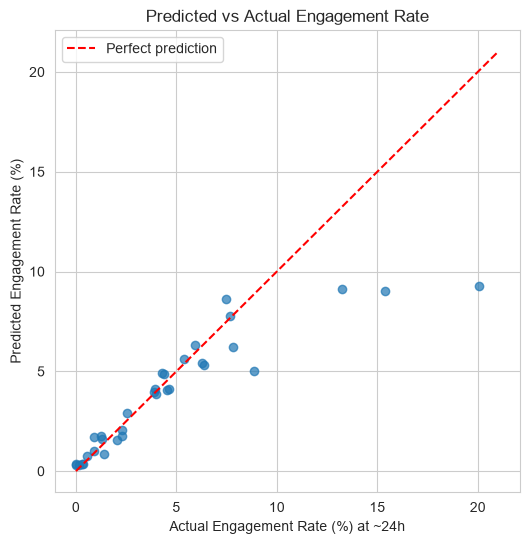

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Engagement Rate (%) at ~24h")
plt.ylabel("Predicted Engagement Rate (%)")
plt.title("Predicted vs Actual Engagement Rate")
plt.legend()
plt.show()

## 4. Feature importance
Shows which early signals the model relies on most to predict future
engagement — good for explaining WHY a prediction was made, not just WHAT
it predicted.

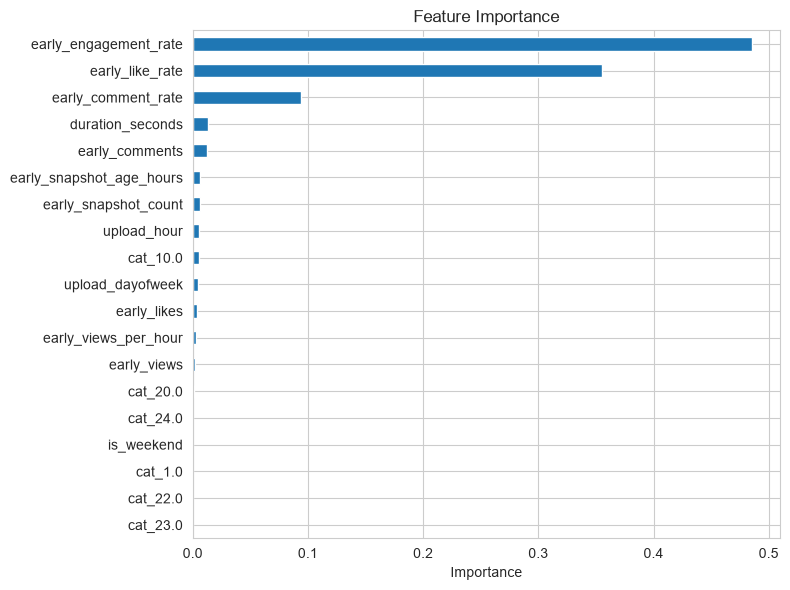

early_engagement_rate       0.485519
early_like_rate             0.355680
early_comment_rate          0.094128
duration_seconds            0.013206
early_comments              0.012504
early_snapshot_age_hours    0.006517
early_snapshot_count        0.006248
upload_hour                 0.005597
cat_10.0                    0.005580
upload_dayofweek            0.004352
early_likes                 0.003677
early_views_per_hour        0.002479
early_views                 0.002197
cat_20.0                    0.001341
cat_24.0                    0.000374
is_weekend                  0.000334
cat_1.0                     0.000132
cat_22.0                    0.000082
cat_23.0                    0.000054
dtype: float64


In [6]:
final_model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
final_model.fit(X, y)

importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances)

## 5. Save the final model (trained on ALL 162 videos) for Day 4
We also save the exact list/order of feature columns, since the live
polling script (Day 4) must build its feature vector in the SAME shape
(same one-hot columns, same order) for the model to work correctly.

In [7]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(final_model, MODEL_PATH)
joblib.dump(list(X.columns), FEATURE_LIST_PATH)

print(f"Saved model to {MODEL_PATH}")
print(f"Saved feature column list to {FEATURE_LIST_PATH}")

Saved model to C:/Users/Lenovo/youtube_enagagement_project/models/engagement_model.pkl
Saved feature column list to C:/Users/Lenovo/youtube_enagagement_project/models/feature_columns.pkl
